# Analyze Extracted Skills (Post-Processing - Multi-File Version)

**This notebook analyzes already-extracted skill data from multiple parquet files in a folder.**

✅ **Benefits:**
- No need to re-run extraction (saves hours)
- Can analyze results even if extraction was interrupted
- Quick iteration on different analyses
- Works with partial results
- **Processes all parquet files in a folder automatically**

**Use case:** You've already run `extract_skills_from_jd.ipynb` and have results in multiple parquet files.

In [1]:
import analyze_extracted_skills_multifile

## Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import json
from datetime import datetime
from glob import glob

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette('husl')

print("✓ Imports successful")

✓ Imports successful


## Configuration

**Edit these paths to match your data:**

In [2]:
# =====================================================================
# EDIT THESE PATHS
# =====================================================================
# Folder containing extracted skills parquet files
OUTPUT_FOLDER = '../data/extracted_skills_production'

# Pattern to match parquet files (adjust if needed)
FILE_PATTERN = '*_skills.parquet'  # Matches: part_rg_00000_skills.parquet, etc.

# Column names (adjust if your parquet has different column names)
SKILLS_COLUMN = 'skills'              # List of extracted skills
NUM_SKILLS_COLUMN = 'num_skills'      # Number of skills
BY_SECTION_COLUMN = 'by_section'      # Skills grouped by section (dict)
ONET_CODE_COLUMN = 'onet_code'        # ONET occupation code
DATE_COLUMN = 'post_date'             # Job posting date
JD_TEXT_COLUMN = 'description'    # Original JD text (if available)

# Analysis options
TOP_N_SKILLS = 20                     # Show top N most common skills
TOP_N_ONET = 10                       # Show top N ONET codes

# =====================================================================

# Find all matching parquet files
INPUT_FILES = sorted(glob(f'{OUTPUT_FOLDER}/{FILE_PATTERN}'))

print(f"Configuration:")
print(f"  Input folder: {OUTPUT_FOLDER}")
print(f"  File pattern: {FILE_PATTERN}")
print(f"  Found {len(INPUT_FILES)} files:")
for i, f in enumerate(INPUT_FILES, 1):
    print(f"    {i}. {Path(f).name}")
print(f"  Top skills to show: {TOP_N_SKILLS}")
print(f"  Top ONET codes to show: {TOP_N_ONET}")

Configuration:
  Input folder: ../data/extracted_skills_production
  File pattern: *_skills.parquet
  Found 197 files:
    1. part_rg_00000_skills.parquet
    2. part_rg_00001_skills.parquet
    3. part_rg_00002_skills.parquet
    4. part_rg_00003_skills.parquet
    5. part_rg_00004_skills.parquet
    6. part_rg_00005_skills.parquet
    7. part_rg_00006_skills.parquet
    8. part_rg_00007_skills.parquet
    9. part_rg_00008_skills.parquet
    10. part_rg_00009_skills.parquet
    11. part_rg_00010_skills.parquet
    12. part_rg_00011_skills.parquet
    13. part_rg_00012_skills.parquet
    14. part_rg_00013_skills.parquet
    15. part_rg_00014_skills.parquet
    16. part_rg_00015_skills.parquet
    17. part_rg_00016_skills.parquet
    18. part_rg_00017_skills.parquet
    19. part_rg_00018_skills.parquet
    20. part_rg_00019_skills.parquet
    21. part_rg_00020_skills.parquet
    22. part_rg_00021_skills.parquet
    23. part_rg_00022_skills.parquet
    24. part_rg_00023_skills.parquet
  

## Step 1: Load All Extracted Skills Data

Load all parquet files in the folder and combine them into a single DataFrame.

In [ ]:
# Check if files exist
if not INPUT_FILES:
    print(f"❌ No files found matching pattern: {OUTPUT_FOLDER}/{FILE_PATTERN}")
    print(f"\nMake sure you've run the extraction notebook first!")
    print(f"Expected folder location: {Path(OUTPUT_FOLDER).absolute()}")
else:
    print(f"Loading {len(INPUT_FILES)} parquet files...\n")
    
    # Load all files and combine them
    dfs = []
    total_size = 0
    
    for i, file_path in enumerate(INPUT_FILES, 1):
        file_size = Path(file_path).stat().st_size / 1024**2
        total_size += file_size
        print(f"  [{i}/{len(INPUT_FILES)}] Loading {Path(file_path).name} ({file_size:.1f} MB)...")
        
        df_temp = pd.read_parquet(file_path)
        dfs.append(df_temp)
        print(f"         → {len(df_temp):,} records")
    
    # Concatenate all dataframes
    print(f"\nCombining {len(dfs)} dataframes...")
    df = pd.concat(dfs, ignore_index=True)
    
    print(f"\n{'='*70}")
    print(f"✓ Successfully loaded and combined all files!")
    print(f"{'='*70}")
    print(f"\nTotal records: {len(df):,}")
    print(f"Total size: {total_size:.1f} MB")
    print(f"\nColumns: {list(df.columns)}")
    
    # Show sample
    print(f"\nSample data:")
    display(df.head(3))
    
    # Show data types
    print(f"\nData types:")
    print(df.dtypes)

Loading 197 parquet files...

  [1/197] Loading part_rg_00000_skills.parquet (190.8 MB)...
         → 78,787 records
  [2/197] Loading part_rg_00001_skills.parquet (191.6 MB)...
         → 78,623 records
  [3/197] Loading part_rg_00002_skills.parquet (192.4 MB)...
         → 79,129 records
  [4/197] Loading part_rg_00003_skills.parquet (192.7 MB)...
         → 79,439 records
  [5/197] Loading part_rg_00004_skills.parquet (192.1 MB)...
         → 79,176 records
  [6/197] Loading part_rg_00005_skills.parquet (191.4 MB)...
         → 78,921 records
  [7/197] Loading part_rg_00006_skills.parquet (191.4 MB)...
         → 79,008 records
  [8/197] Loading part_rg_00007_skills.parquet (191.0 MB)...
         → 78,761 records
  [9/197] Loading part_rg_00008_skills.parquet (191.4 MB)...
         → 79,060 records
  [10/197] Loading part_rg_00009_skills.parquet (191.4 MB)...
         → 78,925 records
  [11/197] Loading part_rg_00010_skills.parquet (191.3 MB)...
         → 78,893 records
  [12/197] 

## Step 2: Data Quality Check

In [4]:
print("="*70)
print("DATA QUALITY CHECK")
print("="*70)

print(f"\nTotal records: {len(df):,}")

if DATE_COLUMN in df.columns:
    print(f"Date range: {df[DATE_COLUMN].min()} to {df[DATE_COLUMN].max()}")

print(f"\nMissing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing': missing.values,
    'Percentage': missing_pct.values
})
print(missing_df[missing_df['Missing'] > 0].to_string(index=False))

if NUM_SKILLS_COLUMN in df.columns:
    print(f"\nSkills per JD statistics:")
    print(df[NUM_SKILLS_COLUMN].describe())
    
    # Check for empty skill lists
    empty_skills = (df[NUM_SKILLS_COLUMN] == 0).sum()
    if empty_skills > 0:
        print(f"\n⚠️ Warning: {empty_skills:,} JDs ({empty_skills/len(df)*100:.1f}%) have 0 extracted skills")

DATA QUALITY CHECK

Total records: 1,106,050
Date range: 2012-02-28 to 2025-01-04

Missing values:
          Column  Missing  Percentage
       title_raw     1134    0.102527
title_translated   200199   18.100357
    job_category     9157    0.827901
        role_k50     9157    0.827901
       role_k150     9157    0.827901
       role_k300     9157    0.827901
       role_k500     9157    0.827901
      role_k1000     9157    0.827901
      role_k1250     9157    0.827901
    location_raw     6834    0.617874
          salary    22341    2.019891
     remove_date    23935    2.164007
  expected_hires     1982    0.179196
        jobtitle   200257   18.105601
      salary_min   737787   66.704670
      salary_max   737787   66.704670
salary_predicted    22341    2.019891

Skills per JD statistics:
count    1.106050e+06
mean     8.430747e+00
std      5.718645e+00
min      0.000000e+00
25%      4.000000e+00
50%      8.000000e+00
75%      1.200000e+01
max      6.700000e+01
Name: num_skil

## Step 3: Overall Skill Statistics

In [1]:
if SKILLS_COLUMN in df.columns:
    # Count all skills across all JDs
    all_skills = []
    for skills_list in df[SKILLS_COLUMN]:
        if isinstance(skills_list, list):
            all_skills.extend(skills_list)
    
    skill_counter = Counter(all_skills)
    unique_skills = len(skill_counter)
    total_skills = sum(skill_counter.values())
    
    print("="*70)
    print("OVERALL SKILL STATISTICS")
    print("="*70)
    print(f"\nTotal skill mentions: {total_skills:,}")
    print(f"Unique skills: {unique_skills:,}")
    print(f"Average mentions per skill: {total_skills/unique_skills:.1f}")
    
    # Top skills
    top_skills = skill_counter.most_common(TOP_N_SKILLS)
    
    print(f"\nTop {TOP_N_SKILLS} Most Common Skills:")
    print(f"{'Rank':<6} {'Skill':<40} {'Count':<10} {'% of JDs'}")
    print("-" * 70)
    for i, (skill, count) in enumerate(top_skills, 1):
        pct = (count / len(df)) * 100
        print(f"{i:<6} {skill:<40} {count:<10,} {pct:>6.1f}%")

NameError: name 'SKILLS_COLUMN' is not defined

## Step 4: Skill Distribution Visualization

In [7]:
if SKILLS_COLUMN in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Top skills bar chart
    top_20 = skill_counter.most_common(20)
    skills = [s[0] for s in top_20]
    counts = [s[1] for s in top_20]
    
    axes[0, 0].barh(range(len(skills)), counts, color='steelblue', edgecolor='black')
    axes[0, 0].set_yticks(range(len(skills)))
    axes[0, 0].set_yticklabels(skills, fontsize=10)
    axes[0, 0].invert_yaxis()
    axes[0, 0].set_xlabel('Number of Mentions')
    axes[0, 0].set_title('Top 20 Most Common Skills')
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # Add counts to bars
    for i, (skill, count) in enumerate(top_20):
        axes[0, 0].text(count, i, f' {count:,}', va='center', fontsize=9)
    
    # 2. Skills per JD distribution
    if NUM_SKILLS_COLUMN in df.columns:
        axes[0, 1].hist(df[NUM_SKILLS_COLUMN], bins=50, color='coral', edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(df[NUM_SKILLS_COLUMN].mean(), color='red', 
                          linestyle='--', linewidth=2, label=f"Mean: {df[NUM_SKILLS_COLUMN].mean():.1f}")
        axes[0, 1].axvline(df[NUM_SKILLS_COLUMN].median(), color='green', 
                          linestyle='--', linewidth=2, label=f"Median: {df[NUM_SKILLS_COLUMN].median():.1f}")
        axes[0, 1].set_xlabel('Number of Skills')
        axes[0, 1].set_ylabel('Number of Job Descriptions')
        axes[0, 1].set_title('Distribution of Skills per Job Description')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)
    
    # 3. Skill frequency distribution (long tail)
    freq_counts = Counter(skill_counter.values())
    frequencies = sorted(freq_counts.keys())
    counts_of_freqs = [freq_counts[f] for f in frequencies]
    
    axes[1, 0].scatter(frequencies, counts_of_freqs, alpha=0.6, s=30, color='purple')
    axes[1, 0].set_xscale('log')
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_xlabel('Frequency (number of mentions)')
    axes[1, 0].set_ylabel('Number of skills with that frequency')
    axes[1, 0].set_title('Skill Frequency Distribution (Log-Log)')
    axes[1, 0].grid(alpha=0.3, which='both')
    
    # 4. Cumulative percentage
    sorted_counts = sorted(skill_counter.values(), reverse=True)
    cumsum = np.cumsum(sorted_counts)
    cumsum_pct = (cumsum / cumsum[-1]) * 100
    
    axes[1, 1].plot(range(1, len(cumsum_pct) + 1), cumsum_pct, color='darkgreen', linewidth=2)
    axes[1, 1].axhline(80, color='red', linestyle='--', linewidth=1, alpha=0.7, label='80% threshold')
    axes[1, 1].axhline(90, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='90% threshold')
    axes[1, 1].set_xlabel('Number of Skills (ranked by frequency)')
    axes[1, 1].set_ylabel('Cumulative % of Total Mentions')
    axes[1, 1].set_title('Cumulative Distribution of Skill Mentions')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    axes[1, 1].set_xscale('log')
    
    # Find how many skills account for 80% of mentions
    idx_80 = np.argmax(cumsum_pct >= 80)
    idx_90 = np.argmax(cumsum_pct >= 90)
    axes[1, 1].text(0.95, 0.05, 
                   f"Top {idx_80} skills = 80% of mentions\nTop {idx_90} skills = 90% of mentions",
                   transform=axes[1, 1].transAxes,
                   ha='right', va='bottom',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

IndexError: index -1 is out of bounds for axis 0 with size 0

Error in callback <function _draw_all_if_interactive at 0x7c5986aad120> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 1600x1200 with 4 Axes>

## Step 5: Skills by Section Analysis

In [8]:
if BY_SECTION_COLUMN in df.columns:
    # Count skills by section
    section_counts = Counter()
    
    for by_section in df[BY_SECTION_COLUMN]:
        if isinstance(by_section, dict):
            for section, skills in by_section.items():
                if isinstance(skills, list):
                    section_counts[section] += len(skills)
    
    print("="*70)
    print("SKILLS BY SECTION")
    print("="*70)
    print(f"\n{'Section':<30} {'Total Skills':<15} {'% of Total'}")
    print("-" * 70)
    
    total_section_skills = sum(section_counts.values())
    for section, count in section_counts.most_common():
        pct = (count / total_section_skills) * 100
        print(f"{section:<30} {count:<15,} {pct:>6.1f}%")
    
    # Visualize
    if section_counts:
        plt.figure(figsize=(12, 6))
        sections = [s[0] for s in section_counts.most_common()]
        counts = [s[1] for s in section_counts.most_common()]
        
        plt.barh(range(len(sections)), counts, color='teal', edgecolor='black', alpha=0.7)
        plt.yticks(range(len(sections)), sections)
        plt.xlabel('Number of Skills')
        plt.title('Total Skills by Job Description Section')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        
        # Add counts to bars
        for i, count in enumerate(counts):
            plt.text(count, i, f' {count:,}', va='center')
        
        plt.tight_layout()
        plt.show()

SKILLS BY SECTION

Section                        Total Skills    % of Total
----------------------------------------------------------------------


## Step 6: ONET Code Analysis

TOP ONET OCCUPATION CODES

Rank   ONET Code       Count      % of Total
----------------------------------------------------------------------
1      41-1011.00      52,605        4.8%
2      51-9198.00      28,994        2.6%
3      15-1252.00      27,341        2.5%
4      53-7065.00      24,454        2.2%
5      13-2051.00      22,472        2.0%
6      11-2011.00      21,337        1.9%
7      35-3041.00      20,611        1.9%
8      15-1241.00      20,481        1.9%
9      43-4051.00      19,536        1.8%
10     13-1111.00      19,188        1.7%


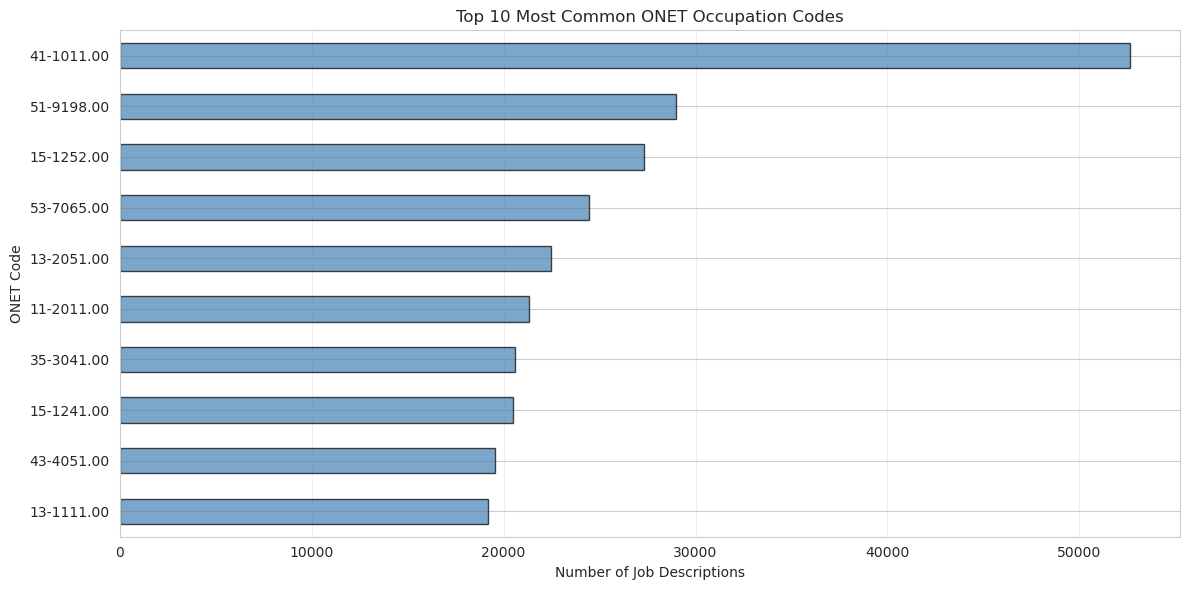

In [6]:
if ONET_CODE_COLUMN in df.columns:
    onet_counts = df[ONET_CODE_COLUMN].value_counts()
    top_onet_codes = onet_counts.head(TOP_N_ONET)
    
    print("="*70)
    print("TOP ONET OCCUPATION CODES")
    print("="*70)
    print(f"\n{'Rank':<6} {'ONET Code':<15} {'Count':<10} {'% of Total'}")
    print("-" * 70)
    
    for i, (code, count) in enumerate(top_onet_codes.items(), 1):
        pct = (count / len(df)) * 100
        print(f"{i:<6} {code:<15} {count:<10,} {pct:>6.1f}%")
    
    # Visualize
    plt.figure(figsize=(12, 6))
    top_onet_codes.plot(kind='barh', color='steelblue', edgecolor='black', alpha=0.7)
    plt.xlabel('Number of Job Descriptions')
    plt.ylabel('ONET Code')
    plt.title(f'Top {TOP_N_ONET} Most Common ONET Occupation Codes')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## Step 7: Skills by ONET Code

In [10]:
if ONET_CODE_COLUMN in df.columns and SKILLS_COLUMN in df.columns:
    # Analyze skills for each top ONET code
    print("="*70)
    print("TOP SKILLS BY ONET CODE")
    print("="*70)
    
    top_3_onet = onet_counts.head(3)
    
    for onet_code in top_3_onet.index:
        # Filter JDs for this ONET code
        onet_jds = df[df[ONET_CODE_COLUMN] == onet_code]
        
        # Count skills for this ONET code
        onet_skills = []
        for skills_list in onet_jds[SKILLS_COLUMN]:
            if isinstance(skills_list, list):
                onet_skills.extend(skills_list)
        
        onet_skill_counter = Counter(onet_skills)
        top_10_onet_skills = onet_skill_counter.most_common(10)
        
        print(f"\nONET Code: {onet_code} ({len(onet_jds):,} JDs)")
        print(f"{'Rank':<6} {'Skill':<40} {'Count':<10} {'% of JDs in code'}")
        print("-" * 70)
        
        for i, (skill, count) in enumerate(top_10_onet_skills, 1):
            pct = (count / len(onet_jds)) * 100
            print(f"{i:<6} {skill:<40} {count:<10,} {pct:>6.1f}%")

TOP SKILLS BY ONET CODE

ONET Code: 41-1011.00 (11,185 JDs)
Rank   Skill                                    Count      % of JDs in code
----------------------------------------------------------------------

ONET Code: 51-9198.00 (6,202 JDs)
Rank   Skill                                    Count      % of JDs in code
----------------------------------------------------------------------

ONET Code: 15-1252.00 (5,944 JDs)
Rank   Skill                                    Count      % of JDs in code
----------------------------------------------------------------------


## Step 8: Time Series Analysis

TIME SERIES ANALYSIS

Skills per JD over time (by quarter):

year_quarter      mean  median      std  count
      2012Q1  9.000000     9.0      NaN      1
      2014Q2  4.750000     5.0 0.500000      4
      2014Q3  5.000000     7.0 3.464102      3
      2014Q4  5.666667     5.0 2.081666      3
      2015Q1  3.000000     3.0      NaN      1
      2015Q4 16.000000    16.0      NaN      1
      2016Q1 13.000000    13.0      NaN      1
      2016Q3  6.000000     7.0 2.669143    186
      2016Q4  6.785714     7.0 3.945369     14
      2017Q1  8.000000     8.0 0.000000      3
      2017Q2  7.400000     8.0 3.306559     10
      2017Q3  4.866667     3.0 3.044120     15
      2017Q4  3.090909     3.0 0.301511     11
      2018Q1  1.666667     2.0 1.505545      6
      2018Q2  4.600000     3.0 2.971291     15
      2018Q3  6.058824     3.0 4.801960     17
      2018Q4  3.922330     3.0 3.527731    103
      2019Q1  1.748201     0.0 2.949866    278
      2019Q2  6.657143     7.0 3.999589    175

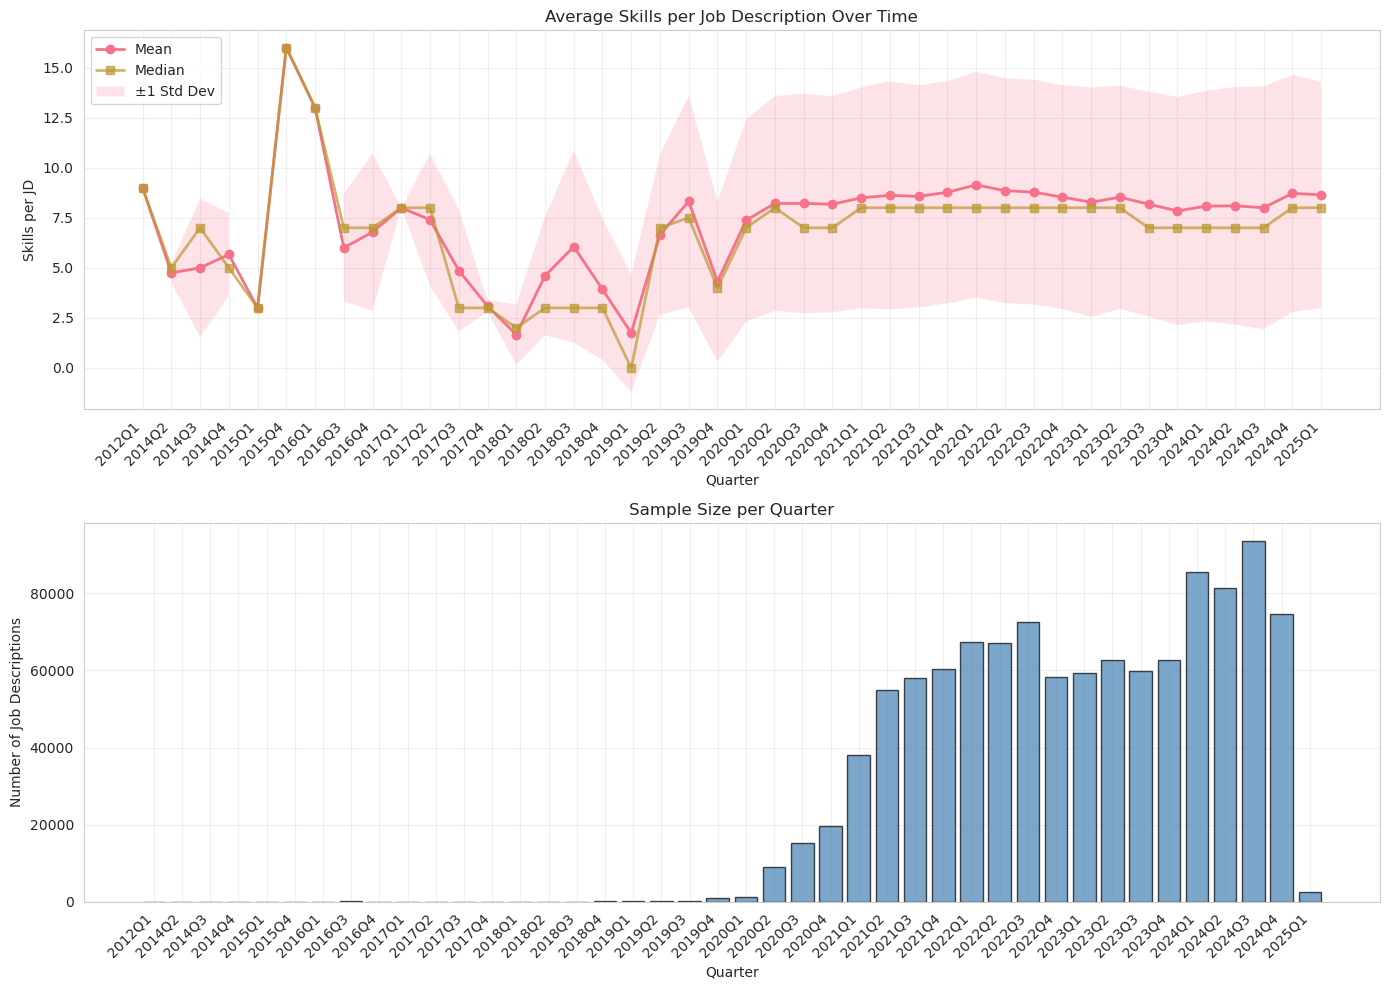

In [7]:
if DATE_COLUMN in df.columns and NUM_SKILLS_COLUMN in df.columns:
    # Convert to datetime if needed
    if not pd.api.types.is_datetime64_any_dtype(df[DATE_COLUMN]):
        df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors='coerce')
    
    # Filter out invalid dates
    df_time = df[df[DATE_COLUMN].notna()].copy()
    
    if len(df_time) > 0:
        # Create year-quarter column
        df_time['year_quarter'] = df_time[DATE_COLUMN].dt.to_period('Q')
        
        # Group by quarter and calculate statistics
        quarterly_stats = df_time.groupby('year_quarter')[NUM_SKILLS_COLUMN].agg([
            'mean', 'median', 'std', 'count'
        ]).reset_index()
        
        print("="*70)
        print("TIME SERIES ANALYSIS")
        print("="*70)
        print(f"\nSkills per JD over time (by quarter):\n")
        print(quarterly_stats.to_string(index=False))
        
        # Visualize
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))
        
        # Convert period to string for plotting
        x_labels = [str(q) for q in quarterly_stats['year_quarter']]
        
        # Average skills over time
        axes[0].plot(x_labels, quarterly_stats['mean'], 
                    marker='o', linewidth=2, markersize=6, label='Mean')
        axes[0].plot(x_labels, quarterly_stats['median'], 
                    marker='s', linewidth=2, markersize=6, label='Median', alpha=0.7)
        axes[0].fill_between(range(len(x_labels)), 
                             quarterly_stats['mean'] - quarterly_stats['std'],
                             quarterly_stats['mean'] + quarterly_stats['std'],
                             alpha=0.2, label='±1 Std Dev')
        axes[0].set_xlabel('Quarter')
        axes[0].set_ylabel('Skills per JD')
        axes[0].set_title('Average Skills per Job Description Over Time')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # Sample size over time
        axes[1].bar(x_labels, quarterly_stats['count'], color='steelblue', edgecolor='black', alpha=0.7)
        axes[1].set_xlabel('Quarter')
        axes[1].set_ylabel('Number of Job Descriptions')
        axes[1].set_title('Sample Size per Quarter')
        axes[1].grid(True, alpha=0.3)
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No valid dates found in the data")
else:
    print("⚠️ Date column not available for time series analysis")

## Step 9: Skill Co-occurrence Analysis

Find which skills frequently appear together in job descriptions.

In [12]:
if SKILLS_COLUMN in df.columns:
    # Analyze co-occurrence for top skills
    top_5_skills = [s[0] for s in skill_counter.most_common(5)]
    
    print("="*70)
    print("SKILL CO-OCCURRENCE ANALYSIS")
    print("="*70)
    print(f"\nAnalyzing co-occurrence for top 5 skills...\n")
    
    for target_skill in top_5_skills:
        # Find JDs that have this skill
        jds_with_skill = df[df[SKILLS_COLUMN].apply(
            lambda x: target_skill in x if isinstance(x, list) else False
        )]
        
        # Count other skills that appear with this skill
        co_occurring_skills = []
        for skills_list in jds_with_skill[SKILLS_COLUMN]:
            if isinstance(skills_list, list):
                co_occurring_skills.extend([s for s in skills_list if s != target_skill])
        
        co_occur_counter = Counter(co_occurring_skills)
        top_co_occur = co_occur_counter.most_common(5)
        
        print(f"Skills that commonly appear with '{target_skill}':")
        for skill, count in top_co_occur:
            pct = (count / len(jds_with_skill)) * 100
            print(f"  - {skill:40s} {count:5,} ({pct:5.1f}%)")
        print()

SKILL CO-OCCURRENCE ANALYSIS

Analyzing co-occurrence for top 5 skills...



## Step 10: Export Summary Report

Save a summary of the analysis to a JSON file.

In [ ]:
# Create summary report
summary = {
    'generated_at': datetime.now().isoformat(),
    'input_files': [Path(f).name for f in INPUT_FILES],
    'input_folder': OUTPUT_FOLDER,
    'total_files': len(INPUT_FILES),
    'total_jds': len(df),
    'date_range': {
        'start': str(df[DATE_COLUMN].min()) if DATE_COLUMN in df.columns else None,
        'end': str(df[DATE_COLUMN].max()) if DATE_COLUMN in df.columns else None
    },
    'skills_per_jd': {
        'mean': float(df[NUM_SKILLS_COLUMN].mean()) if NUM_SKILLS_COLUMN in df.columns else None,
        'median': float(df[NUM_SKILLS_COLUMN].median()) if NUM_SKILLS_COLUMN in df.columns else None,
        'std': float(df[NUM_SKILLS_COLUMN].std()) if NUM_SKILLS_COLUMN in df.columns else None,
        'min': float(df[NUM_SKILLS_COLUMN].min()) if NUM_SKILLS_COLUMN in df.columns else None,
        'max': float(df[NUM_SKILLS_COLUMN].max()) if NUM_SKILLS_COLUMN in df.columns else None
    },
    'total_unique_skills': unique_skills if SKILLS_COLUMN in df.columns else None,
    'top_skills': [(skill, int(count)) for skill, count in top_skills[:10]] if SKILLS_COLUMN in df.columns else [],
    'skills_by_section': {section: int(count) for section, count in section_counts.items()} if BY_SECTION_COLUMN in df.columns else {},
    'top_onet_codes': [(str(code), int(count)) for code, count in top_onet_codes.items()] if ONET_CODE_COLUMN in df.columns else []
}

# Save to JSON in the output folder
output_json = f"{OUTPUT_FOLDER}/combined_analysis_summary.json"
with open(output_json, 'w') as f:
    json.dump(summary, f, indent=2)

print("="*70)
print("SUMMARY REPORT SAVED")
print("="*70)
print(f"\n✓ Saved analysis summary to: {output_json}")
print(f"\nYou can reload this summary anytime without re-running the analysis.")

## Step 11: AI Impact Dimension Analysis

Analyze extracted skills by their AI Impact Dimension:
- **Replaced by AI**: Skills/tasks that AI can fully automate
- **Augmented by AI**: Skills enhanced by AI tools but requiring human judgment
- **Building/Managing AI**: Skills for developing, deploying, and managing AI systems
- **Resistant to AI**: Skills that are difficult for AI to replicate
- **Transformed by AI**: Skills fundamentally changed by AI capabilities

In [ ]:
# Load AI Impact Dimensions lookup
from pathlib import Path

AI_IMPACT_LOOKUP_PATH = Path('../skillner/data/ksao_ai_impact_lookup.json')

if AI_IMPACT_LOOKUP_PATH.exists():
    with open(AI_IMPACT_LOOKUP_PATH) as f:
        AI_IMPACT_LOOKUP = json.load(f)
    print(f"✓ Loaded AI Impact lookup with {len(AI_IMPACT_LOOKUP):,} KSAOs")
    
    # Show dimension distribution in lookup
    dimension_counts = Counter(v['ai_impact_dimension'] for v in AI_IMPACT_LOOKUP.values())
    print(f"\nKSAOs by AI Impact Dimension:")
    for dim, count in dimension_counts.most_common():
        print(f"  {dim}: {count:,}")
else:
    print(f"⚠️ AI Impact lookup not found at: {AI_IMPACT_LOOKUP_PATH}")
    print("Please ensure the ksao_ai_impact_lookup.json file exists.")
    AI_IMPACT_LOOKUP = {}

In [ ]:
# Map all extracted skills to AI Impact Dimensions
if SKILLS_COLUMN in df.columns and AI_IMPACT_LOOKUP:
    
    # Count skills by AI Impact Dimension
    ai_impact_skill_counts = {
        'Replaced by AI': Counter(),
        'Augmented by AI': Counter(),
        'Building/Managing AI': Counter(),
        'Resistant to AI': Counter(),
        'Transformed by AI': Counter(),
        'Unknown': Counter()
    }
    
    # Total mentions by dimension
    ai_impact_totals = Counter()
    matched_count = 0
    unmatched_count = 0
    unmatched_skills = set()
    
    for skills_list in df[SKILLS_COLUMN]:
        if isinstance(skills_list, list):
            for skill in skills_list:
                skill_lower = skill.lower().strip()
                if skill_lower in AI_IMPACT_LOOKUP:
                    dim = AI_IMPACT_LOOKUP[skill_lower]['ai_impact_dimension']
                    ai_impact_skill_counts[dim][skill] += 1
                    ai_impact_totals[dim] += 1
                    matched_count += 1
                else:
                    ai_impact_skill_counts['Unknown'][skill] += 1
                    ai_impact_totals['Unknown'] += 1
                    unmatched_count += 1
                    unmatched_skills.add(skill)
    
    total_mentions = matched_count + unmatched_count
    
    print("="*70)
    print("SKILLS BY AI IMPACT DIMENSION")
    print("="*70)
    print(f"\nTotal skill mentions: {total_mentions:,}")
    print(f"Matched to AI Impact: {matched_count:,} ({matched_count/total_mentions*100:.1f}%)")
    print(f"Unmatched: {unmatched_count:,} ({unmatched_count/total_mentions*100:.1f}%)")
    
    print(f"\n{'AI Impact Dimension':<25} {'Mentions':<12} {'% of Total':<12} {'Unique Skills'}")
    print("-" * 70)
    
    for dim in ['Replaced by AI', 'Augmented by AI', 'Building/Managing AI', 
                'Resistant to AI', 'Transformed by AI', 'Unknown']:
        count = ai_impact_totals[dim]
        unique = len(ai_impact_skill_counts[dim])
        pct = (count / total_mentions) * 100 if total_mentions > 0 else 0
        print(f"{dim:<25} {count:<12,} {pct:<12.1f} {unique:,}")
    
    print(f"\nTop 10 'Unknown' skills (not in AI Impact lookup):")
    for skill, count in ai_impact_skill_counts['Unknown'].most_common(10):
        print(f"  - {skill}: {count:,}")
else:
    print("⚠️ Cannot perform AI Impact analysis: missing skills column or lookup")

In [ ]:
# Visualize AI Impact Dimension distribution
if AI_IMPACT_LOOKUP and ai_impact_totals:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Define colors for each dimension
    dim_colors = {
        'Replaced by AI': '#e74c3c',      # Red
        'Augmented by AI': '#3498db',     # Blue
        'Building/Managing AI': '#9b59b6', # Purple
        'Resistant to AI': '#27ae60',     # Green
        'Transformed by AI': '#f39c12',   # Orange
        'Unknown': '#95a5a6'              # Gray
    }
    
    # 1. Pie chart of AI Impact Dimensions (excluding Unknown)
    dims_for_pie = ['Replaced by AI', 'Augmented by AI', 'Building/Managing AI', 
                    'Resistant to AI', 'Transformed by AI']
    pie_values = [ai_impact_totals[d] for d in dims_for_pie]
    pie_colors = [dim_colors[d] for d in dims_for_pie]
    
    axes[0, 0].pie(pie_values, labels=dims_for_pie, colors=pie_colors, 
                   autopct='%1.1f%%', startangle=90, explode=[0.02]*5)
    axes[0, 0].set_title('Skills by AI Impact Dimension\n(Matched Skills Only)', fontsize=12)
    
    # 2. Bar chart of all dimensions including Unknown
    all_dims = ['Replaced by AI', 'Augmented by AI', 'Building/Managing AI', 
                'Resistant to AI', 'Transformed by AI', 'Unknown']
    bar_values = [ai_impact_totals[d] for d in all_dims]
    bar_colors = [dim_colors[d] for d in all_dims]
    
    bars = axes[0, 1].barh(all_dims, bar_values, color=bar_colors, edgecolor='black', alpha=0.8)
    axes[0, 1].set_xlabel('Number of Skill Mentions')
    axes[0, 1].set_title('Skill Mentions by AI Impact Dimension', fontsize=12)
    axes[0, 1].grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, bar_values):
        axes[0, 1].text(val + max(bar_values)*0.01, bar.get_y() + bar.get_height()/2, 
                       f'{val:,}', va='center', fontsize=10)
    
    # 3. Top skills per dimension (select 3 dimensions)
    dims_to_show = ['Replaced by AI', 'Augmented by AI', 'Transformed by AI']
    top_per_dim = []
    labels = []
    colors = []
    
    for dim in dims_to_show:
        top_5 = ai_impact_skill_counts[dim].most_common(5)
        for skill, count in top_5:
            top_per_dim.append(count)
            labels.append(f"{skill[:25]}..." if len(skill) > 25 else skill)
            colors.append(dim_colors[dim])
    
    y_pos = range(len(labels))
    axes[1, 0].barh(y_pos, top_per_dim, color=colors, edgecolor='black', alpha=0.8)
    axes[1, 0].set_yticks(y_pos)
    axes[1, 0].set_yticklabels(labels, fontsize=9)
    axes[1, 0].set_xlabel('Number of Mentions')
    axes[1, 0].set_title('Top 5 Skills per AI Impact Dimension\n(Replaced, Augmented, Transformed)', fontsize=12)
    axes[1, 0].grid(axis='x', alpha=0.3)
    axes[1, 0].invert_yaxis()
    
    # Add horizontal lines to separate dimensions
    axes[1, 0].axhline(y=4.5, color='black', linestyle='--', alpha=0.5)
    axes[1, 0].axhline(y=9.5, color='black', linestyle='--', alpha=0.5)
    
    # 4. Unique skills count per dimension
    unique_counts = [len(ai_impact_skill_counts[d]) for d in all_dims]
    axes[1, 1].bar(all_dims, unique_counts, color=bar_colors, edgecolor='black', alpha=0.8)
    axes[1, 1].set_ylabel('Number of Unique Skills')
    axes[1, 1].set_title('Unique Skills by AI Impact Dimension', fontsize=12)
    axes[1, 1].tick_params(axis='x', rotation=30)
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    for i, (dim, count) in enumerate(zip(all_dims, unique_counts)):
        axes[1, 1].text(i, count + max(unique_counts)*0.02, f'{count:,}', 
                       ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Time series analysis: AI Impact Dimensions over time
if DATE_COLUMN in df.columns and AI_IMPACT_LOOKUP and SKILLS_COLUMN in df.columns:
    print("="*70)
    print("AI IMPACT DIMENSIONS OVER TIME")
    print("="*70)
    
    # Add AI Impact dimension counts per JD
    def get_ai_impact_counts(skills_list):
        """Count skills by AI Impact Dimension for a single JD."""
        counts = {
            'Replaced by AI': 0,
            'Augmented by AI': 0,
            'Building/Managing AI': 0,
            'Resistant to AI': 0,
            'Transformed by AI': 0,
            'Unknown': 0
        }
        if isinstance(skills_list, list):
            for skill in skills_list:
                skill_lower = skill.lower().strip()
                if skill_lower in AI_IMPACT_LOOKUP:
                    dim = AI_IMPACT_LOOKUP[skill_lower]['ai_impact_dimension']
                    counts[dim] += 1
                else:
                    counts['Unknown'] += 1
        return counts
    
    # Calculate AI impact counts for each JD (sample for efficiency if large)
    sample_size = min(100000, len(df))
    if len(df) > sample_size:
        print(f"\nUsing random sample of {sample_size:,} JDs for time series analysis...")
        df_time_sample = df.sample(n=sample_size, random_state=42).copy()
    else:
        df_time_sample = df.copy()
    
    # Get AI impact counts
    ai_impact_per_jd = df_time_sample[SKILLS_COLUMN].apply(get_ai_impact_counts)
    
    # Expand the dict into columns
    for dim in ['Replaced by AI', 'Augmented by AI', 'Building/Managing AI', 
                'Resistant to AI', 'Transformed by AI']:
        df_time_sample[f'ai_{dim.replace(" ", "_").replace("/", "_").lower()}'] = \
            ai_impact_per_jd.apply(lambda x: x[dim])
    
    # Ensure date column is datetime
    if not pd.api.types.is_datetime64_any_dtype(df_time_sample[DATE_COLUMN]):
        df_time_sample[DATE_COLUMN] = pd.to_datetime(df_time_sample[DATE_COLUMN], errors='coerce')
    
    # Filter valid dates
    df_time_sample = df_time_sample[df_time_sample[DATE_COLUMN].notna()]
    df_time_sample['year_quarter'] = df_time_sample[DATE_COLUMN].dt.to_period('Q')
    
    # Aggregate by quarter
    ai_cols = [c for c in df_time_sample.columns if c.startswith('ai_')]
    quarterly_ai = df_time_sample.groupby('year_quarter')[ai_cols].mean().reset_index()
    
    print(f"\nAverage skills per JD by AI Impact Dimension (quarterly):")
    print(quarterly_ai.tail(10).to_string(index=False))
else:
    print("⚠️ Cannot perform time series analysis: missing date column or AI Impact lookup")

In [ ]:
# Visualize AI Impact Dimensions over time
if 'quarterly_ai' in dir() and len(quarterly_ai) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot columns and labels
    dim_mapping = {
        'ai_replaced_by_ai': ('Replaced by AI', '#e74c3c'),
        'ai_augmented_by_ai': ('Augmented by AI', '#3498db'),
        'ai_building_managing_ai': ('Building/Managing AI', '#9b59b6'),
        'ai_resistant_to_ai': ('Resistant to AI', '#27ae60'),
        'ai_transformed_by_ai': ('Transformed by AI', '#f39c12')
    }
    
    x_labels = [str(q) for q in quarterly_ai['year_quarter']]
    
    # 1. Stacked area chart showing composition over time
    ax1 = axes[0]
    bottom = np.zeros(len(quarterly_ai))
    
    for col, (label, color) in dim_mapping.items():
        if col in quarterly_ai.columns:
            values = quarterly_ai[col].values
            ax1.fill_between(range(len(x_labels)), bottom, bottom + values, 
                           label=label, color=color, alpha=0.7)
            bottom = bottom + values
    
    ax1.set_xticks(range(0, len(x_labels), max(1, len(x_labels)//15)))
    ax1.set_xticklabels([x_labels[i] for i in range(0, len(x_labels), max(1, len(x_labels)//15))], 
                       rotation=45, ha='right')
    ax1.set_ylabel('Average Skills per JD')
    ax1.set_title('AI Impact Dimension Composition Over Time', fontsize=12)
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. Line chart showing trends for each dimension
    ax2 = axes[1]
    
    for col, (label, color) in dim_mapping.items():
        if col in quarterly_ai.columns:
            ax2.plot(range(len(x_labels)), quarterly_ai[col].values, 
                    label=label, color=color, linewidth=2, marker='o', markersize=3)
    
    ax2.set_xticks(range(0, len(x_labels), max(1, len(x_labels)//15)))
    ax2.set_xticklabels([x_labels[i] for i in range(0, len(x_labels), max(1, len(x_labels)//15))], 
                       rotation=45, ha='right')
    ax2.set_xlabel('Quarter')
    ax2.set_ylabel('Average Skills per JD')
    ax2.set_title('AI Impact Dimension Trends Over Time', fontsize=12)
    ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nSummary: Change from first to last quarter")
    print("-" * 60)
    for col, (label, _) in dim_mapping.items():
        if col in quarterly_ai.columns:
            first_val = quarterly_ai[col].iloc[0]
            last_val = quarterly_ai[col].iloc[-1]
            change = ((last_val - first_val) / first_val * 100) if first_val > 0 else 0
            trend = "↑" if change > 0 else "↓" if change < 0 else "→"
            print(f"{label:<25}: {first_val:.2f} → {last_val:.2f} ({trend} {abs(change):.1f}%)")

In [ ]:
# AI Impact Analysis by ONET Code: Which occupations are most at risk?
if ONET_CODE_COLUMN in df.columns and AI_IMPACT_LOOKUP and SKILLS_COLUMN in df.columns:
    print("="*70)
    print("AI IMPACT RISK BY ONET OCCUPATION CODE")
    print("="*70)
    
    # Calculate AI impact profile for each ONET code
    onet_ai_profiles = []
    
    for onet_code in df[ONET_CODE_COLUMN].value_counts().head(50).index:
        onet_df = df[df[ONET_CODE_COLUMN] == onet_code]
        
        dim_counts = Counter()
        total_skills = 0
        
        for skills_list in onet_df[SKILLS_COLUMN]:
            if isinstance(skills_list, list):
                for skill in skills_list:
                    skill_lower = skill.lower().strip()
                    if skill_lower in AI_IMPACT_LOOKUP:
                        dim = AI_IMPACT_LOOKUP[skill_lower]['ai_impact_dimension']
                        dim_counts[dim] += 1
                        total_skills += 1
        
        if total_skills > 0:
            profile = {
                'onet_code': onet_code,
                'jd_count': len(onet_df),
                'total_skills': total_skills,
                'pct_replaced': dim_counts['Replaced by AI'] / total_skills * 100,
                'pct_augmented': dim_counts['Augmented by AI'] / total_skills * 100,
                'pct_building': dim_counts['Building/Managing AI'] / total_skills * 100,
                'pct_resistant': dim_counts['Resistant to AI'] / total_skills * 100,
                'pct_transformed': dim_counts['Transformed by AI'] / total_skills * 100,
            }
            # Risk score: higher = more skills replaced/transformed by AI
            profile['ai_risk_score'] = profile['pct_replaced'] + 0.5 * profile['pct_transformed']
            onet_ai_profiles.append(profile)
    
    onet_ai_df = pd.DataFrame(onet_ai_profiles)
    
    # Sort by AI risk score
    onet_ai_df = onet_ai_df.sort_values('ai_risk_score', ascending=False)
    
    print("\nTop 15 ONET codes with highest AI replacement risk:")
    print("-" * 90)
    print(f"{'ONET Code':<15} {'JDs':>8} {'Replaced%':>10} {'Augmented%':>10} {'Build/Mgmt%':>10} {'Risk Score':>12}")
    print("-" * 90)
    
    for _, row in onet_ai_df.head(15).iterrows():
        print(f"{row['onet_code']:<15} {row['jd_count']:>8,} {row['pct_replaced']:>10.1f} "
              f"{row['pct_augmented']:>10.1f} {row['pct_building']:>10.1f} {row['ai_risk_score']:>12.1f}")
    
    print("\n\nTop 10 ONET codes with LOWEST AI replacement risk (most resistant):")
    print("-" * 90)
    for _, row in onet_ai_df.tail(10).iterrows():
        print(f"{row['onet_code']:<15} {row['jd_count']:>8,} {row['pct_replaced']:>10.1f} "
              f"{row['pct_augmented']:>10.1f} {row['pct_resistant']:>10.1f} {row['ai_risk_score']:>12.1f}")

In [ ]:
# Visualize AI Impact by ONET Code
if 'onet_ai_df' in dir() and len(onet_ai_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # 1. Horizontal bar chart: AI Risk Score by ONET code (top 20)
    top_20_risk = onet_ai_df.head(20)
    
    colors = plt.cm.RdYlGn_r(top_20_risk['ai_risk_score'] / top_20_risk['ai_risk_score'].max())
    
    axes[0].barh(range(len(top_20_risk)), top_20_risk['ai_risk_score'], 
                color=colors, edgecolor='black', alpha=0.8)
    axes[0].set_yticks(range(len(top_20_risk)))
    axes[0].set_yticklabels(top_20_risk['onet_code'])
    axes[0].set_xlabel('AI Risk Score (% Replaced + 0.5 × % Transformed)')
    axes[0].set_title('Top 20 ONET Codes by AI Replacement Risk', fontsize=12)
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].invert_yaxis()
    
    # 2. Stacked bar showing composition for top 15 codes
    top_15 = onet_ai_df.head(15)
    
    dims = ['pct_replaced', 'pct_augmented', 'pct_building', 'pct_resistant', 'pct_transformed']
    dim_labels = ['Replaced', 'Augmented', 'Building/Managing', 'Resistant', 'Transformed']
    dim_colors = ['#e74c3c', '#3498db', '#9b59b6', '#27ae60', '#f39c12']
    
    left = np.zeros(len(top_15))
    for dim, label, color in zip(dims, dim_labels, dim_colors):
        axes[1].barh(range(len(top_15)), top_15[dim], left=left, 
                    label=label, color=color, alpha=0.8)
        left += top_15[dim].values
    
    axes[1].set_yticks(range(len(top_15)))
    axes[1].set_yticklabels(top_15['onet_code'])
    axes[1].set_xlabel('Percentage of Skills')
    axes[1].set_title('AI Impact Dimension Composition by ONET Code', fontsize=12)
    axes[1].legend(loc='lower right')
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

## Custom Analysis Section

Use this section for your own custom analyses.

In [ ]:
# Your custom analysis code here
# Example: Filter by specific ONET code
# df_software_engineers = df[df[ONET_CODE_COLUMN] == '15-1252.00']

# Example: Find emerging skills (increasing over time)
# ...

# Example: Compare skills across industries
# ...